In [1]:
# ╔══════════════════════════════════════════════════════════╗
# ║          SMART WASTE BIN — UNIFIED PIPELINE              ║
# ╚══════════════════════════════════════════════════════════╝

# Install dependencies (run once, then restart runtime if prompted)
%pip install -q tensorflow==2.19.0 opencv-python-headless numpy pillow


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 645.0/645.0 MB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 53.8 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
tf-keras 2.20.0 requires tensorflow<2.21,>=2.20, but you have tensorflow 2.19.0 which is incompatible.
tensorflow-text 2.20.1 requires tensorflow<2.21,>=2.20.0, but you have tensorflow 2.19.0 which is incompatible.
ydf-tf 2.20.0 requires tensorflow==2.20.0, but you have tensorflow 2.19.0 which is incompatible.


  SMART WASTE BIN — LOADING MODELS

📦 Loading Liquid Detection Model...


   ✅ input shape: (None, 224, 224, 3)

📦 Loading Component Detection Model...


   ✅ input shape: (None, 224, 224, 3)

📦 Loading Binary Classification Model...
   ✅ input shape: (None, 224, 224, 3)

📦 Loading Category Classification Model...
   ✅ input shape: (None, 299, 299, 3)

✅ ALL MODELS READY

📤 Upload an image to test the pipeline...


/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 36 variables whereas the saved optimizer has 60 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


Saving empty_test_nestle.jpeg to empty_test_nestle.jpeg


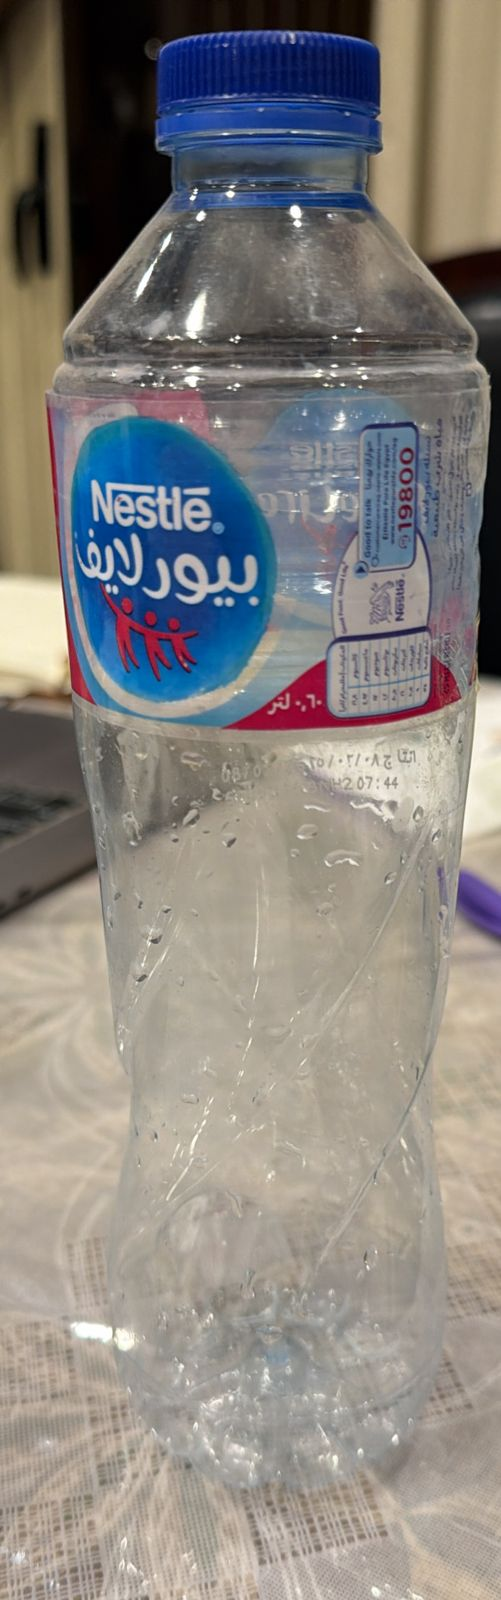


  PROCESSING: empty_test_nestle.jpeg

🔍 Stage 1 · Liquid Detection
   raw=0.7499  →  ✅ No liquid  (75.0%)

🔍 Stage 2 · Component Detection
   raw=0.9897  →  ✅ Single component  (99.0%)

🔍 Stage 3 · Waste Classification
   ♻️  RECYCLABLE — PLASTIC  (100.0%)

  🎯 DECISION CODE : 3
  📢 ACTION        : Dispensing to Plastic recyclable compartment


In [3]:
# ── Imports ─────────────────────────────────────────────────
import os, io, cv2, numpy as np
import tensorflow as tf
from tensorflow.keras.models import load_model
from tensorflow.keras.applications.densenet import preprocess_input as densenet_preprocess
from tensorflow.keras.applications.xception import preprocess_input as xception_preprocess
from google.colab import files
import IPython.display as display

# ── Model paths — update if needed ──────────────────────────
LIQUID_MODEL_PATH    = 'final_adjusted_liquid_advance.h5'
COMPONENT_MODEL_PATH = 'component_model_fixed_v3.h5'
BINARY_MODEL_PATH    = 'DenseNet121_binary_v2.keras'
CATEGORY_MODEL_PATH  = 'xception_4classes.keras'

LIQUID_THRESHOLD    = 0.5
COMPONENT_THRESHOLD = 0.5

# ── Class mapping ────────────────────────────────────────────
_ORIGINAL_FOLDERS = sorted([
    'automobile wastes', 'battery waste', 'E-waste', 'glass waste',
    'light bulbs', 'metal waste', 'paper waste', 'plastic waste', 'organic waste'
])
_CLASS_MAPPING = {
    'paper waste': 'Paper', 'plastic waste': 'Plastic', 'organic waste': 'Organic',
    'E-waste': 'Other', 'automobile wastes': 'Other', 'battery waste': 'Other',
    'glass waste': 'Other', 'light bulbs': 'Other', 'metal waste': 'Other'
}
XCEPTION_TO_WASTE = {i: _CLASS_MAPPING[f] for i, f in enumerate(_ORIGINAL_FOLDERS)}

# ════════════════════════════════════════════════════════════
# LOAD ALL MODELS (runs once)
# ════════════════════════════════════════════════════════════
print('=' * 60)
print('  SMART WASTE BIN — LOADING MODELS')
print('=' * 60)

print('\n📦 Loading Liquid Detection Model...')
liquid_model = load_model(LIQUID_MODEL_PATH)
print(f'   ✅ input shape: {liquid_model.input_shape}')

print('\n📦 Loading Component Detection Model...')
component_model = load_model(
    COMPONENT_MODEL_PATH,
    custom_objects={'preprocess_input': tf.keras.applications.mobilenet_v2.preprocess_input}
)
print(f'   ✅ input shape: {component_model.input_shape}')

print('\n📦 Loading Binary Classification Model...')
binary_model = load_model(BINARY_MODEL_PATH)
print(f'   ✅ input shape: {binary_model.input_shape}')

print('\n📦 Loading Category Classification Model...')
category_model = load_model(CATEGORY_MODEL_PATH)
print(f'   ✅ input shape: {category_model.input_shape}')

print('\n✅ ALL MODELS READY')
print('=' * 60)

# ════════════════════════════════════════════════════════════
# PIPELINE HELPERS
# ════════════════════════════════════════════════════════════

def _prep_224(image_bgr):
    """Resize BGR image to float32 (1,224,224,3) batch, no normalisation."""
    rgb = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)
    return np.expand_dims(cv2.resize(rgb, (224, 224)).astype('float32'), 0)

def _detect_liquid(image_bgr):
    pred = liquid_model.predict(_prep_224(image_bgr), verbose=0)[0][0]
    is_liquid = pred < LIQUID_THRESHOLD
    conf = (1 - pred) if is_liquid else pred
    return is_liquid, conf, pred

def _detect_component(image_bgr):
    pred = component_model.predict(_prep_224(image_bgr), verbose=0)[0][0]
    is_multi = pred < COMPONENT_THRESHOLD
    conf = (1 - pred) if is_multi else pred
    return is_multi, conf, pred

def _classify_waste(image_bgr):
    rgb = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)

    # Binary: recyclable vs non-recyclable (DenseNet121, 224x224)
    x_bin   = densenet_preprocess(cv2.resize(rgb, (224, 224)).astype('float32'))
    bin_pred = binary_model.predict(np.expand_dims(x_bin, 0), verbose=0)
    if bin_pred[0].shape[0] == 2:
        bin_class = int(np.argmax(bin_pred[0]))
        bin_conf  = float(np.max(bin_pred[0]))
    else:
        bin_class = int(bin_pred[0][0] > 0.5)
        bin_conf  = float(bin_pred[0][0] if bin_class else 1 - bin_pred[0][0])
    is_recyclable = bin_class == 1

    waste_type = 'Non-recyclable'
    if is_recyclable:
        # Category: which recyclable type (Xception, 299x299)
        x_cat      = xception_preprocess(cv2.resize(rgb, (299, 299)).astype('float32'))
        cat_pred   = category_model.predict(np.expand_dims(x_cat, 0), verbose=0)
        waste_type = XCEPTION_TO_WASTE.get(int(np.argmax(cat_pred[0])), 'Other')

    return is_recyclable, waste_type, bin_conf

# ════════════════════════════════════════════════════════════
# MAIN PIPELINE
# Decision codes:
#   1 = Liquid detected
#   2 = Multi-component detected
#   3 = Plastic recyclable
#   4 = Paper recyclable
#   5 = Organic recyclable
#   6 = Other recyclable
#   7 = Non-recyclable
# ════════════════════════════════════════════════════════════

def run_pipeline(image_bgr, name='image'):
    """Run the full 3-stage pipeline on an OpenCV BGR image."""
    print(f"\n{'='*60}")
    print(f'  PROCESSING: {name}')
    print(f"{'='*60}")

    # Stage 1 — Liquid
    print('\n🔍 Stage 1 · Liquid Detection')
    is_liquid, liq_conf, liq_raw = _detect_liquid(image_bgr)
    print(f'   raw={liq_raw:.4f}  →  {"🚫 LIQUID DETECTED" if is_liquid else "✅ No liquid"}  ({liq_conf:.1%})')
    if is_liquid:
        return _finish({'decision_code': 1, 'message': 'Please empty liquid'})

    # Stage 2 — Multi-component
    print('\n🔍 Stage 2 · Component Detection')
    is_multi, multi_conf, multi_raw = _detect_component(image_bgr)
    print(f'   raw={multi_raw:.4f}  →  {"⚠️ MULTI-COMPONENT" if is_multi else "✅ Single component"}  ({multi_conf:.1%})')
    if is_multi:
        return _finish({'decision_code': 2, 'message': 'Multi-component detected'})

    # Stage 3 — Waste classification
    print('\n🔍 Stage 3 · Waste Classification')
    is_recyclable, waste_type, waste_conf = _classify_waste(image_bgr)
    if is_recyclable:
        code    = {'Plastic': 3, 'Paper': 4, 'Organic': 5}.get(waste_type, 6)
        message = f'Dispensing to {waste_type} recyclable compartment'
        print(f'   ♻️  RECYCLABLE — {waste_type.upper()}  ({waste_conf:.1%})')
    else:
        code, message = 7, 'Dispensing to non-recyclable compartment'
        print(f'   🚮  NON-RECYCLABLE  ({waste_conf:.1%})')

    return _finish({'decision_code': code, 'message': message})

def _finish(result):
    print(f"\n{'='*60}")
    print(f"  🎯 DECISION CODE : {result['decision_code']}")
    print(f"  📢 ACTION        : {result['message']}")
    print(f"{'='*60}")
    return result

# ════════════════════════════════════════════════════════════
# UPLOAD AN IMAGE AND RUN THE PIPELINE
# ════════════════════════════════════════════════════════════
print('\n📤 Upload an image to test the pipeline...')
uploaded = files.upload()   # opens Colab file picker

for filename, data in uploaded.items():
    # Preview the image
    display.display(display.Image(data=data, width=300))

    # Decode bytes -> OpenCV BGR array
    arr   = np.frombuffer(data, dtype=np.uint8)
    image = cv2.imdecode(arr, cv2.IMREAD_COLOR)

    if image is None:
        print(f'❌ Could not decode "{filename}". Use JPEG or PNG.')
        continue

    run_pipeline(image, name=filename)
